In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print(os.getcwd())

/content


In [3]:
!ls

drive  sample_data


In [4]:
data_dir = "/content/drive/MyDrive/data"
data_dir

'/content/drive/MyDrive/data'

PyTorch Vision Transformer (ViT)


In [5]:
# Step 1 - Setup and Imports

In [6]:
!pip install timm pydicom scikit-learn torch torchvision --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.7 MB/s eta 0:00:00


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision.transforms as T
from PIL import Image
import pydicom
import timm

from tqdm import tqdm


In [8]:
# Step 2 - Load Metadata and Prepare Labels

In [9]:
data_dir = "/content/drive/MyDrive/data"
metadata_path = os.path.join(data_dir, "HAM10000_metadata.csv")
metadata = pd.read_csv(metadata_path)
print("Metadata loaded:", metadata.shape)

# Image directories
image_dirs = [
    os.path.join(data_dir, "HAM10000_images_part_1"),
    os.path.join(data_dir, "HAM10000_images_part_2")
]

# Collect all image paths
image_paths = []
for d in image_dirs:
    for fname in sorted(os.listdir(d)):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(d, fname))

print("Total images found:", len(image_paths))

# Match image IDs with metadata labels
image_labels = []
for path in image_paths:
    image_id = os.path.splitext(os.path.basename(path))[0]
    row = metadata.loc[metadata['image_id'] == image_id, 'dx']
    image_labels.append(row.values[0] if not row.empty else "unknown")

# Encode string labels → integer indices
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(image_labels)
class_names = label_encoder.classes_
n_classes = len(class_names)
print("Class mapping:", {i: name for i, name in enumerate(class_names)})

# Compute class weights to reduce imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(encoded_labels),
    y=encoded_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print("Class weights:", class_weights)


Metadata loaded: (10015, 7)
Total images found: 10028
Class mapping: {0: np.str_('akiec'), 1: np.str_('bcc'), 2: np.str_('bkl'), 3: np.str_('df'), 4: np.str_('mel'), 5: np.str_('nv'), 6: np.str_('unknown'), 7: np.str_('vasc')}
Class weights: tensor([ 3.8333,  2.4387,  1.1406, 10.9000,  1.1262,  0.1870, 96.4231,  8.8275])


In [10]:
# Step 3 - Dataset Class (Supports JPG/PNG/DICOM)

In [11]:
class HAM10000Dataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def _read_image(self, path):
        path = Path(path)
        if path.suffix.lower() == ".dcm":
            ds = pydicom.dcmread(str(path))
            arr = ds.pixel_array.astype(np.float32)
            arr = (arr - arr.min()) / (arr.max() + 1e-8) * 255.0
            img = Image.fromarray(arr.astype(np.uint8))
        else:
            img = Image.open(path).convert("RGB")
        return img

    def __getitem__(self, idx):
        img = self._read_image(self.image_paths[idx])
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


In [ ]:
# Step 4 - Train/Val/Test Split

In [12]:
from sklearn.model_selection import train_test_split

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, encoded_labels, test_size=0.2, stratify=encoded_labels, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print("Train:", len(train_paths), "Val:", len(val_paths), "Test:", len(test_paths))


Train: 8022 Val: 1003 Test: 1003


In [13]:
# Step 5 - Transforms

In [14]:
def default_transforms(image_size=224, is_train=True):
    if is_train:
        return T.Compose([
            T.Resize((image_size, image_size)),
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
        ])
    else:
        return T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
        ])


In [15]:
# Step 6 - DataLoaders

In [16]:
img_size = 224
batch_size = 16

train_tf = default_transforms(img_size, True)
val_tf = default_transforms(img_size, False)

train_ds = HAM10000Dataset(train_paths, train_labels, train_tf)
val_ds = HAM10000Dataset(val_paths, val_labels, val_tf)
test_ds = HAM10000Dataset(test_paths, test_labels, val_tf)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [17]:
# Step 7 - Vision Transformer Model

In [18]:
def create_vit_model(model_name="vit_base_patch16_224", num_classes=7, pretrained=True):
    model = timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=num_classes,
        in_chans=3
    )
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_vit_model(num_classes=n_classes, pretrained=True)
model.to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [19]:
# Step 8 - Training and Validation Functions

In [20]:
def train_one_epoch(model, loader, optimizer, device, criterion):
    model.train()
    total_loss, all_preds, all_targets = 0.0, [], []
    for imgs, targets in tqdm(loader, desc="Training", leave=False):
        imgs, targets = imgs.to(device), targets.to(device)
        logits = model(imgs)
        loss = criterion(logits, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
        all_preds.extend(np.argmax(probs, axis=1))
        all_targets.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = np.mean(np.array(all_preds) == np.array(all_targets))
    return avg_loss, acc


def validate(model, loader, device, criterion):
    model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []
    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc="Validating", leave=False):
            imgs, targets = imgs.to(device), targets.to(device)
            logits = model(imgs)
            loss = criterion(logits, targets)
            total_loss += loss.item() * imgs.size(0)

            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            all_preds.extend(np.argmax(probs, axis=1))
            all_targets.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = np.mean(np.array(all_preds) == np.array(all_targets))
    return avg_loss, acc



In [21]:
# Step 9 -Training Loop

Epoch 1/10 | Train Loss: 1.8351, Acc: 0.4180 | Val Loss: 1.6191, Acc: 0.5603
✅ Saved new best model.


Epoch 2/10 | Train Loss: 1.4656, Acc: 0.5365 | Val Loss: 1.3746, Acc: 0.5513


Epoch 3/10 | Train Loss: 1.2859, Acc: 0.5758 | Val Loss: 1.2127, Acc: 0.6849
✅ Saved new best model.


Epoch 4/10 | Train Loss: 1.1836, Acc: 0.6220 | Val Loss: 1.1445, Acc: 0.5603


Epoch 5/10 | Train Loss: 1.0321, Acc: 0.6606 | Val Loss: 1.1257, Acc: 0.6401


Epoch 6/10 | Train Loss: 0.8770, Acc: 0.6940 | Val Loss: 1.2083, Acc: 0.6610


Epoch 7/10 | Train Loss: 0.7644, Acc: 0.7211 | Val Loss: 1.0363, Acc: 0.7228
✅ Saved new best model.


Epoch 8/10 | Train Loss: 0.5726, Acc: 0.7678 | Val Loss: 1.0830, Acc: 0.6859


Epoch 9/10 | Train Loss: 0.4808, Acc: 0.7896 | Val Loss: 1.0107, Acc: 0.7448
✅ Saved new best model.


Epoch 10/10 | Train Loss: 0.4184, Acc: 0.8125 | Val Loss: 1.1267, Acc: 0.7507
✅ Saved new best model.

Training complete. Best Val Accuracy: 0.7507


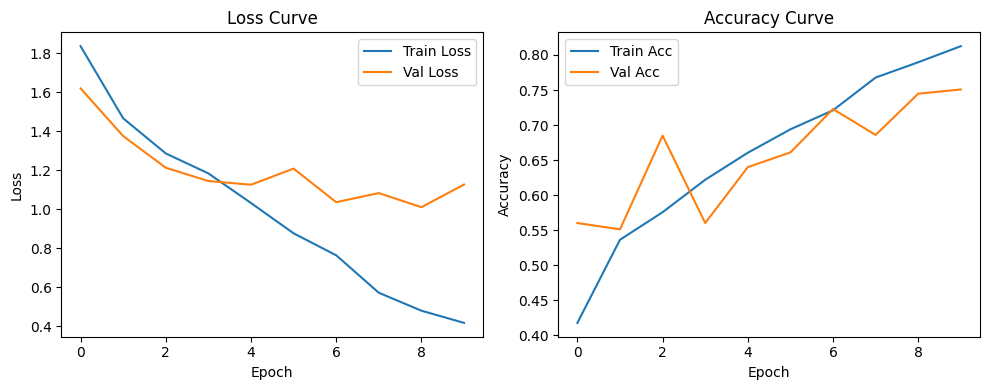

In [22]:
lr = 1e-4
epochs = 10
output_dir = "./vit_ham10000_output"
os.makedirs(output_dir, exist_ok=True)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

# Plot
# Track losses and accuracies
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_acc = 0.0
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device, criterion)
    val_loss, val_acc = validate(model, val_loader, device, criterion)
    scheduler.step()

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), os.path.join(output_dir, "best_vit_ham10000.pth"))
        print("✅ Saved new best model.")

print(f"\nTraining complete. Best Val Accuracy: {best_acc:.4f}")

# Plot loss and accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()


In [23]:
# Step 10 - Evaluate on Test Set

In [24]:
model.load_state_dict(torch.load(os.path.join(output_dir, "best_vit_ham10000.pth")))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, targets in tqdm(test_loader, desc="Testing"):
        imgs, targets = imgs.to(device), targets.to(device)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_targets))
print(f"Test Accuracy: {test_acc:.4f}")


Testing: 100%|██████████| 63/63 [02:35<00:00,  2.47s/it]

Test Accuracy: 0.7597


In [25]:
# Step 11: Prediction on a chosen image

Chosen image: /content/drive/MyDrive/data/HAM10000_images_part_2/ISIC_0031415.jpg


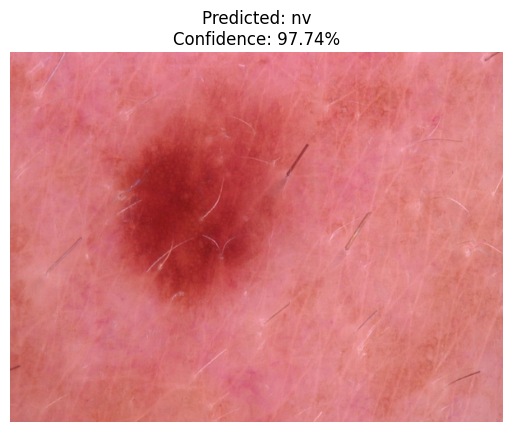

Predicted class: nv
Class probabilities:
akiec: 0.00%
bcc: 0.00%
bkl: 0.07%
df: 0.02%
mel: 0.00%
nv: 97.74%
unknown: 2.17%
vasc: 0.00%


In [26]:
import torch
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

# === Step 11: Prediction on a chosen image ===

# 1️⃣ Choose an image path (can be from test set or any image)
chosen_image_path = test_paths[0]  # example: first test image
print("Chosen image:", chosen_image_path)

# 2️⃣ Define same transforms as validation
predict_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# 3️⃣ Load and preprocess image
img = Image.open(chosen_image_path).convert("RGB")
input_tensor = predict_tf(img).unsqueeze(0).to(device)  # add batch dimension

# 4️⃣ Load best saved model weights
model.load_state_dict(torch.load(os.path.join(output_dir, "best_vit_ham10000.pth"), map_location=device))
model.eval()

# 5️⃣ Predict
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
    pred_idx = np.argmax(probs)
    predicted_class = class_names[pred_idx]

# 6️⃣ Show results
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predicted_class}\nConfidence: {probs[pred_idx]*100:.2f}%")
plt.show()

print("Predicted class:", predicted_class)
print("Class probabilities:")
for i, cls in enumerate(class_names):
    print(f"{cls}: {probs[i]*100:.2f}%")


In [27]:
print(os.listdir("./vit_ham10000_output"))

['best_vit_ham10000.pth']


In [28]:
from google.colab import files
files.download('./vit_ham10000_output/best_vit_ham10000.pth')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>